[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evinracher/3008422-machine-learning/blob/main/week3/workshop/deliverables/housing-exercise.ipynb)


En este notebook se presenta el análisis de datos y la comparación de diferentes modelos de regresión y aprendizaje de máquinas para el dataset `houseprices.csv`.

Este dataset describe las características de las viviendas que fueron vendidas y su precio de venta (SalePrice). Siendo esta la variable objetivo a usar para aplicar los modelos.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos


In [ ]:
HOUSING_PATH = "./content/houseprices.csv"

In [ ]:
import pandas as pd


def load_housing_data(housing_path=HOUSING_PATH):
    return pd.read_csv(housing_path, keep_default_na=False)

In [ ]:
housing = load_housing_data()
housing.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000


# Descripción de los datos


In [ ]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             1460 non-null   int64
 1   MSSubClass     1460 non-null   int64
 2   MSZoning       1460 non-null   str  
 3   LotFrontage    1460 non-null   str  
 4   LotArea        1460 non-null   int64
 5   Street         1460 non-null   str  
 6   Alley          1460 non-null   str  
 7   LotShape       1460 non-null   str  
 8   LandContour    1460 non-null   str  
 9   Utilities      1460 non-null   str  
 10  LotConfig      1460 non-null   str  
 11  LandSlope      1460 non-null   str  
 12  Neighborhood   1460 non-null   str  
 13  Condition1     1460 non-null   str  
 14  Condition2     1460 non-null   str  
 15  BldgType       1460 non-null   str  
 16  HouseStyle     1460 non-null   str  
 17  OverallQual    1460 non-null   int64
 18  OverallCond    1460 non-null   int64
 19  YearBuilt      14

In [ ]:
housing.describe()

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,10516.828082,6.099315,5.575342,1971.267808,1984.865753,443.639726,46.549315,567.240411,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,9981.264932,1.382997,1.112799,30.202904,20.645407,456.098091,161.319273,441.866955,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,223.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,383.500000,0.000000,477.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,712.250000,0.000000,808.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,5644.000000,1474.000000,2336.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Removemos la columna ID ya que no aporta información al problema


In [ ]:
housing = housing.drop(["Id"], axis=1)

## Graficamos los datos


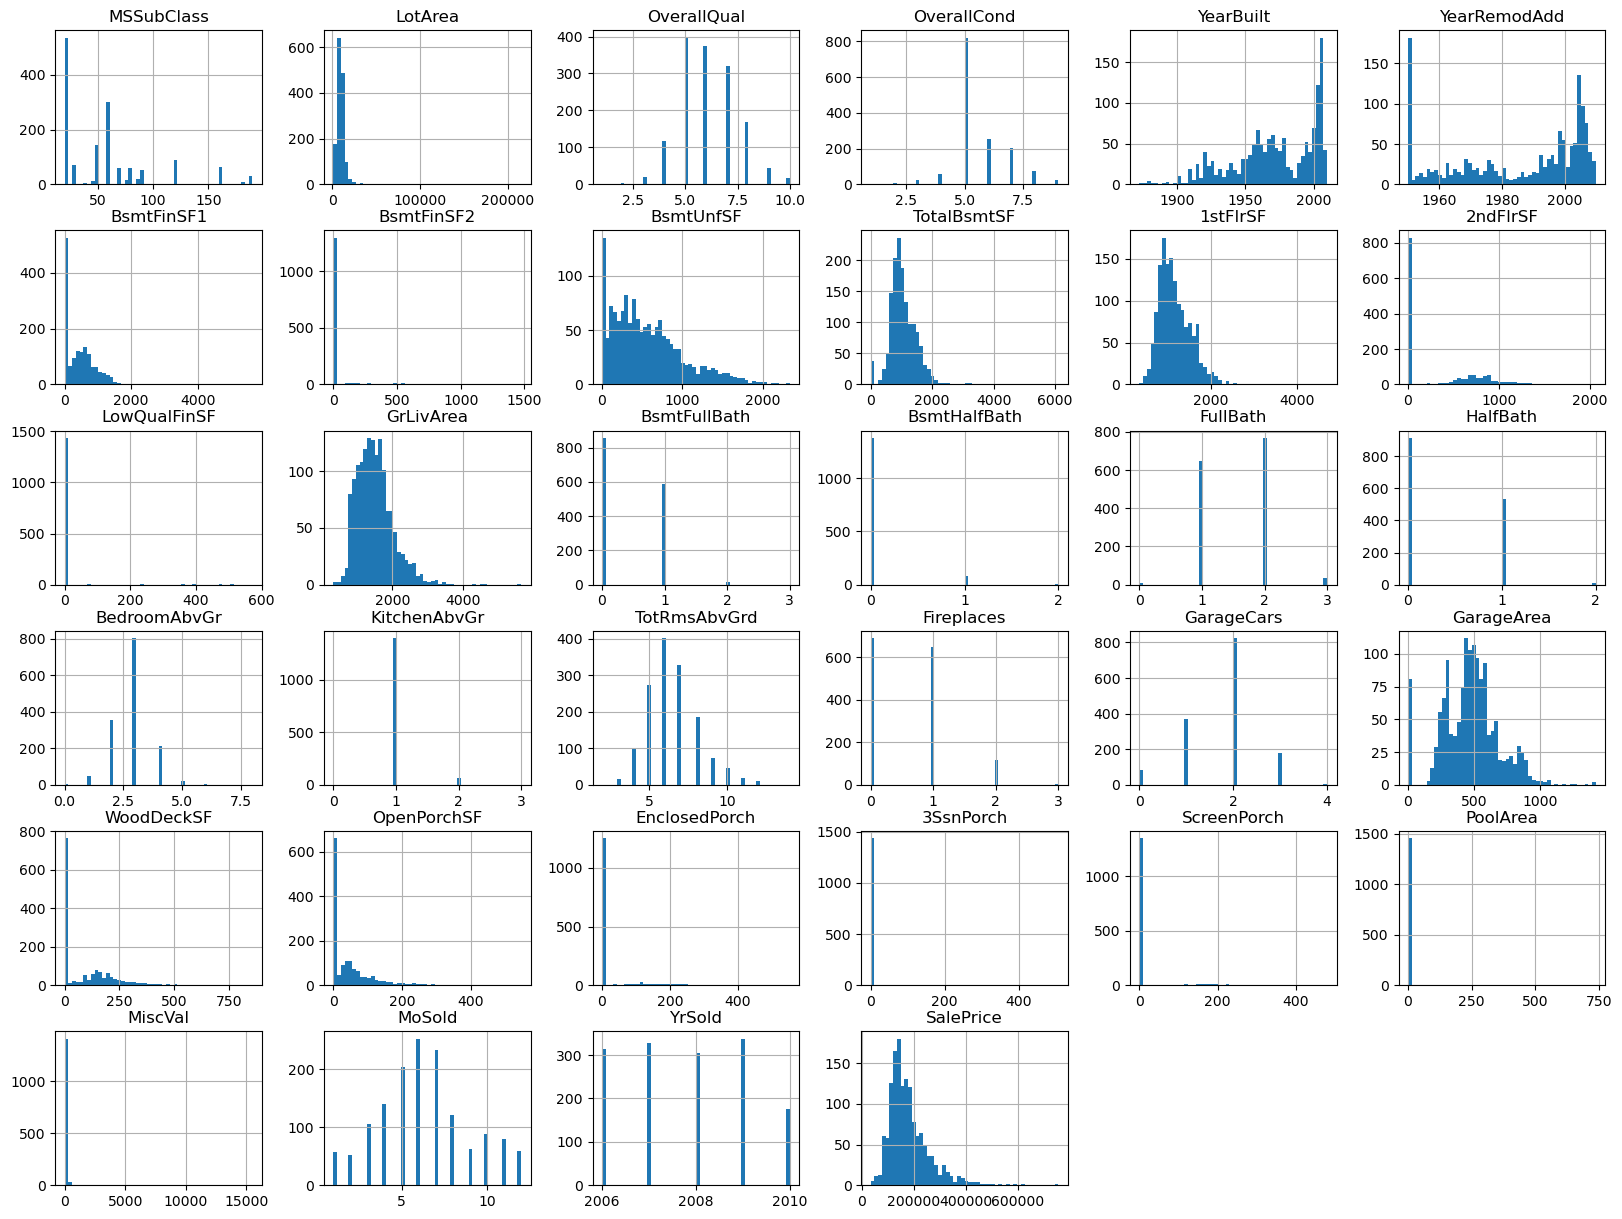

In [ ]:
%matplotlib inline
# needed in jupyter notebook
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20, 15))
plt.show()

In [ ]:
# Configurar el plot
sns.set_palette("GnBu_d")  # Paleta de colores
sns.set_style("whitegrid")

El dataset tiene muchas columnas, por lo cual no se puede hacer el gráfico de dispersión con todas las caracteristicas. Se puede hacer con algunas que a priori se cree tienen relación con la variable objetivo (SalePrice).


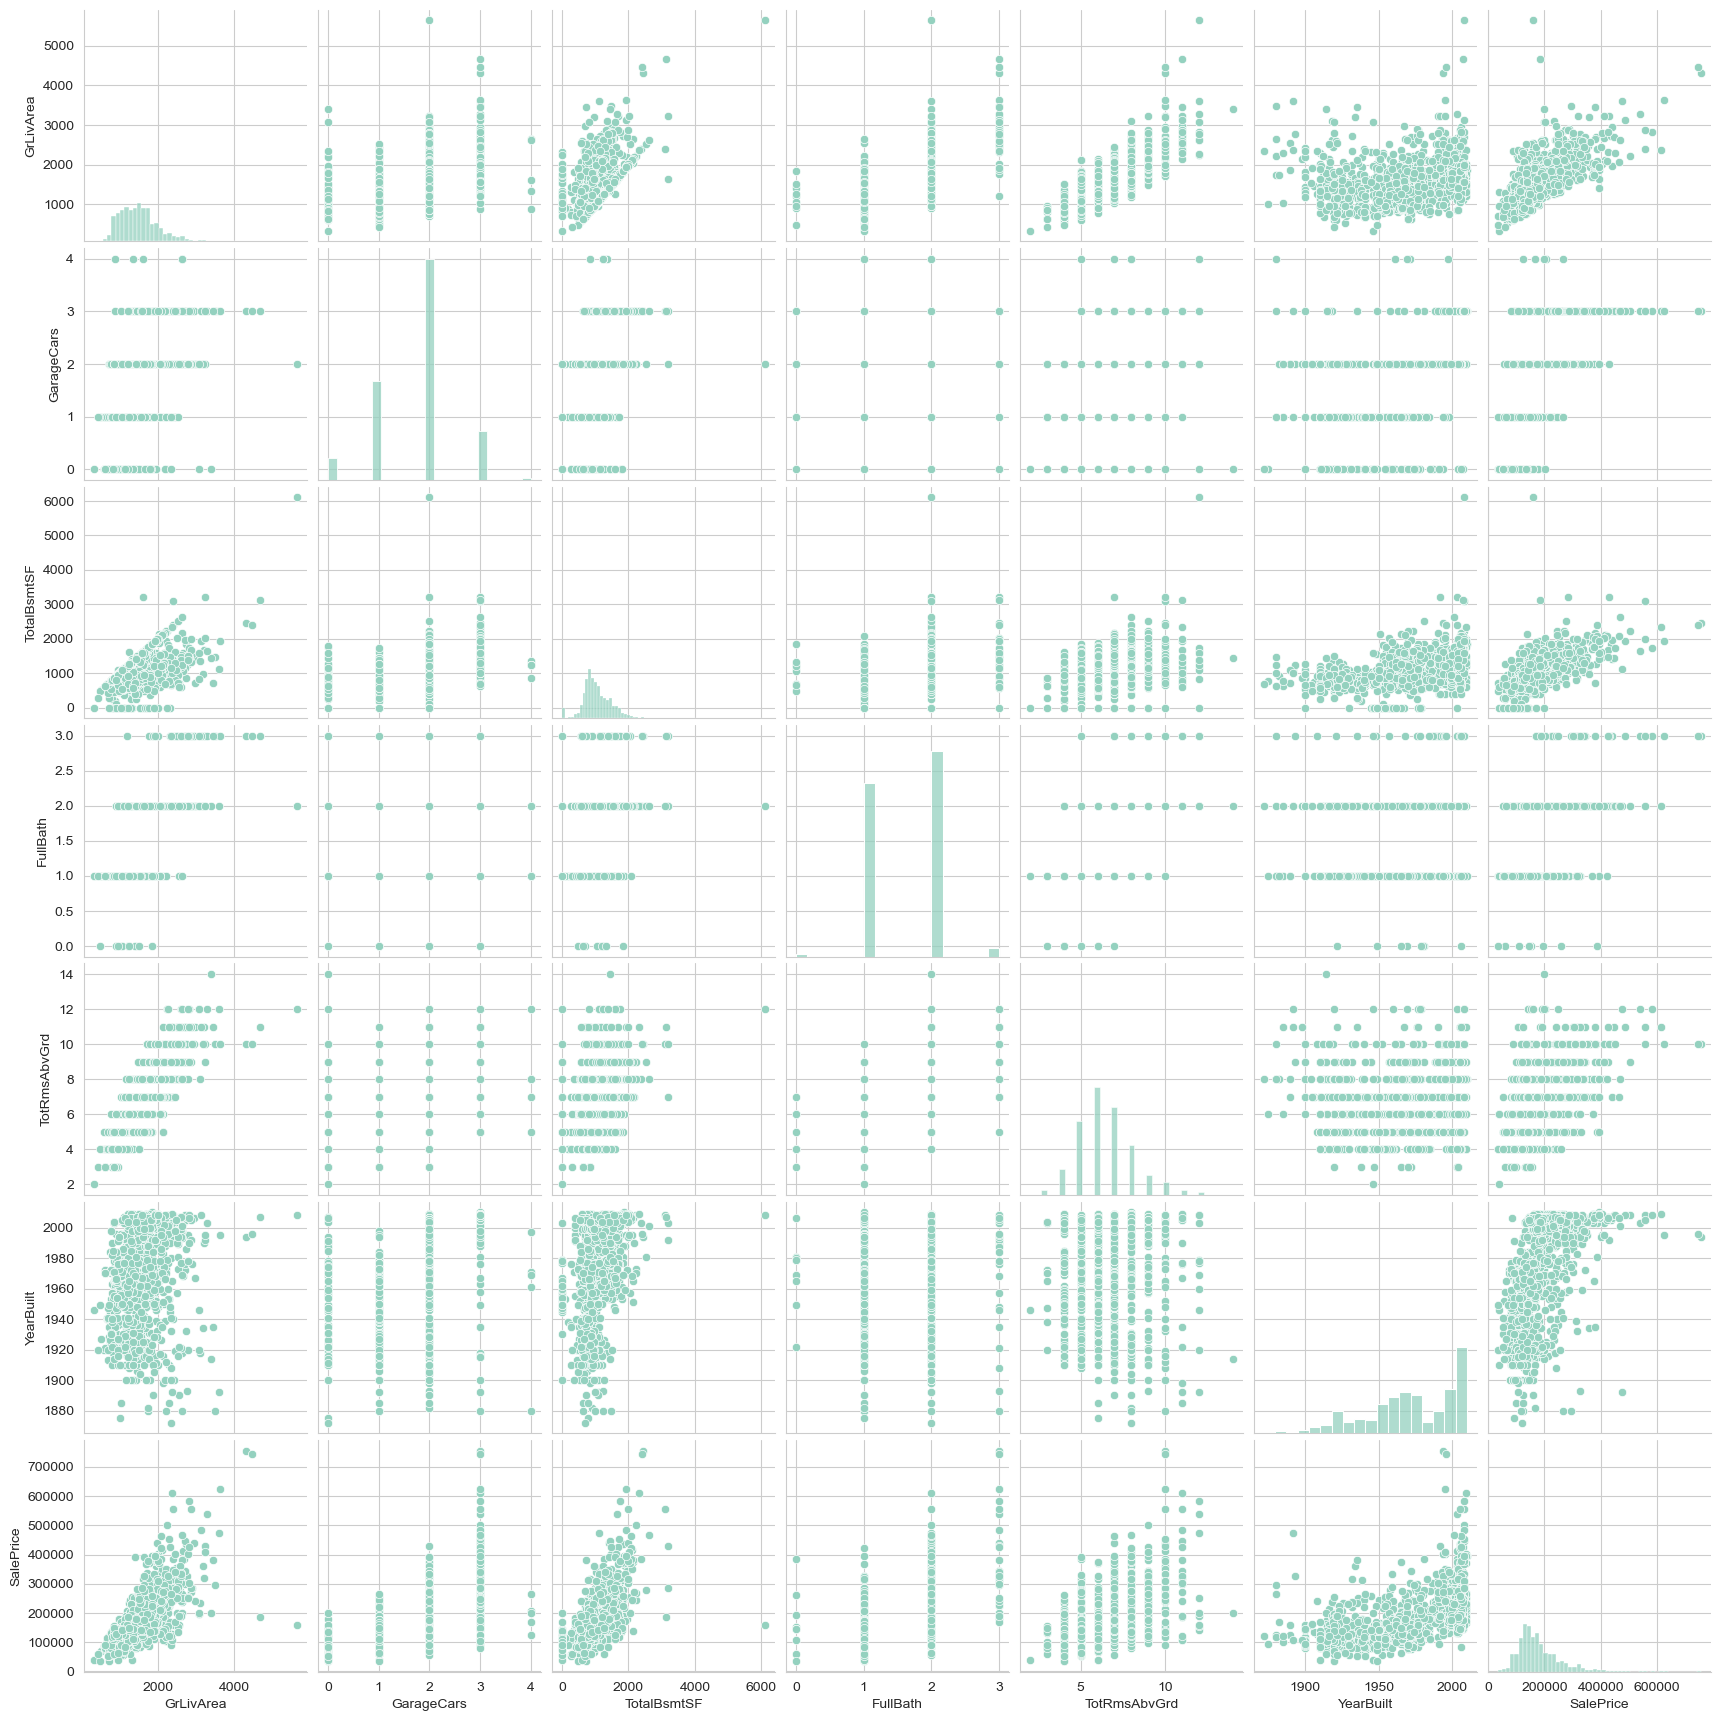

In [ ]:
top_numeric_features = [
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
]

plot_data = housing[top_numeric_features + ["SalePrice"]].replace("NA", np.nan)
plot_data = plot_data.astype(float)

sns.pairplot(plot_data)

Se puede ver que GrLivArea (área habitable) está correlacionada con el SalePrice, así como TotalBsmtSF (área total de la base en ft). También se puede ver que hay variables que son numéricas ordinales, como FullBath (que describe la cantidad de baños) y GarageCars (la cantidad de garages).


In [ ]:
corr_matrix = housing.corr(numeric_only=True)

In [ ]:
corr_matrix["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
Fireplaces       0.466929
BsmtFinSF1       0.386420
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

Se evidencia que hay 10 características que tienen una correlación mayor a 0.5 con SalePrice. Estas características podrían tener un gran peso para los modelos. Siendo OverallQual (calificación general) la que tiene una mayor correlación.


## Dataset de prueba

Separamos los datos de entrada y salida


In [ ]:
X = housing.drop(["SalePrice"], axis=1)
y = housing["SalePrice"]

Seleccionamos el 30% de los datos como dataset de prueba


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

El dataset tiene gran cantidad de variables categóricas, por lo cual se procesan usando OneHot encoding, lo que nos permite usar su valor para entrenar los modelos de machine learning. También debemos reemplazar los valores faltantes utilizando como estrategia el promedio de los datos.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
    "MoSold",
    "YrSold",
]

categorical_features = X_train.drop(columns=numeric_features).columns.tolist()


def prepare_data(source):
    source = source.copy()

    # MSSubClass es una variable categórica
    source["MSSubClass"] = source["MSSubClass"].astype(str)

    # En las variables numéricas, valores como "NA" se convierten en NaN para que puedan ser imputados
    for column in numeric_features:
        source[column] = pd.to_numeric(source[column], errors="coerce")
    return source


X_train = prepare_data(X_train)
print(X_train.shape)

numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    [
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

full_pipeline = ColumnTransformer(
    [
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

X_train_prepared = full_pipeline.fit_transform(X_train)

(1022, 79)


In [ ]:
X_train_prepared.shape

(1022, 313)

# Entrenamiento


A continuación se presenta el entrenamiento de los diferentes modelos a usar para la comparación.

## Regresión lineal


In [ ]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train_prepared, y_train)
len(lm.coef_)

313

**Predicción:**

In [ ]:
X_test = prepare_data(X_test)
X_test_prepared = full_pipeline.transform(X_test)

In [ ]:
y_pred = lm.predict(X_test_prepared)

Text(0, 0.5, 'Predicciones')

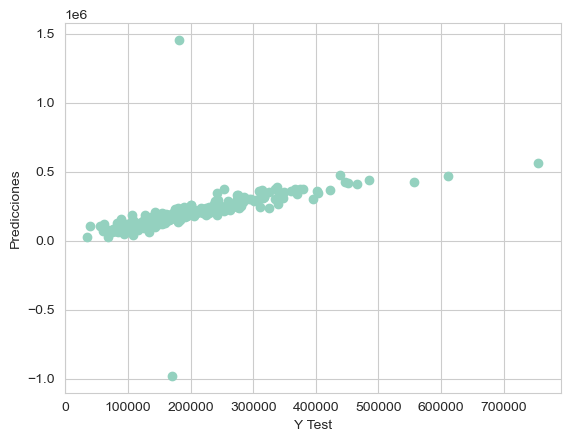

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lm_mbe = mean_absolute_error(y_test, y_pred)
lm_mse = mean_squared_error(y_test, y_pred)
lm_rmse = np.sqrt(lm_mse)
lm_r2s = r2_score(y_test, y_pred)

print("MAE:", lm_mbe)
print("MSE:", lm_mse)
print("RMSE:", lm_rmse)
print("R2_score:", lm_r2s)

MAE: 23709.056110477522
MSE: 7496339250.591014
RMSE: 86581.40245220686
R2_score: -0.07426748728322452


## Regresion lasso

In [ ]:
from sklearn.linear_model import Lasso

r_lasso = Lasso(alpha=0.5)
r_lasso.fit(X_train_prepared, y_train)
len(r_lasso.coef_)

/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.862e+11, tolerance: 6.151e+08
  model = cd_fast.sparse_enet_coordinate_descent(


313

**Predición:**

In [ ]:
y_pred_lasso = r_lasso.predict(X_test_prepared)

Text(0, 0.5, 'Predicciones')

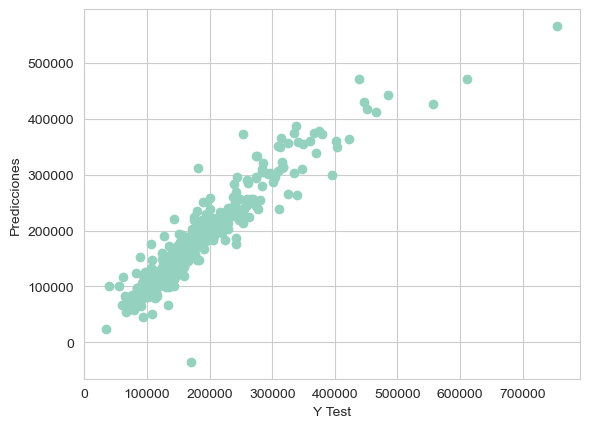

In [ ]:
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_lasso_mbe = mean_absolute_error(y_test, y_pred_lasso)
r_lasso_mse = mean_squared_error(y_test, y_pred_lasso)
r_lasso_rmse = np.sqrt(r_lasso_mse)
r_lasso_r2s = r2_score(y_test, y_pred_lasso)

print("MAE:", r_lasso_mbe)
print("MSE:", r_lasso_mse)
print("RMSE:", r_lasso_rmse)
print("R2_score:", r_lasso_r2s)

MAE: 18778.989373432218
MSE: 863383714.9969299
RMSE: 29383.39182254033
R2_score: 0.8762722679609407


## Regresion Ridge

In [ ]:
from sklearn.linear_model import Ridge

r_ridge = Ridge(alpha=0.5)
r_ridge.fit(X_train_prepared, y_train)
len(r_ridge.coef_)

313

**Predición:**

In [ ]:
y_pred_ridge = r_ridge.predict(X_test_prepared)

Text(0, 0.5, 'Predicciones')

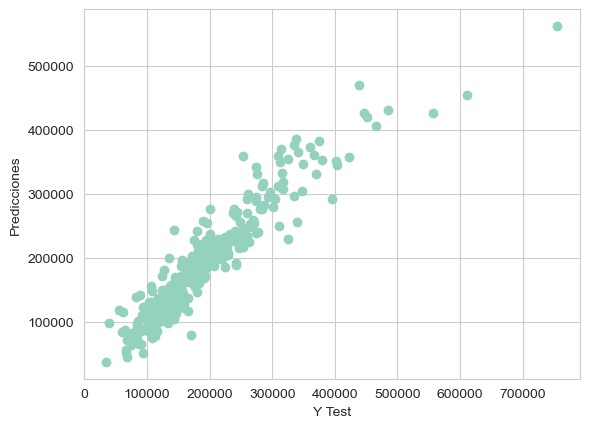

In [ ]:
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_ridge_mbe = mean_absolute_error(y_test, y_pred_ridge)
r_ridge_mse = mean_squared_error(y_test, y_pred_ridge)
r_ridge_rmse = np.sqrt(r_ridge_mse)
r_ridge_r2s = r2_score(y_test, y_pred_ridge)

print("MAE:", r_ridge_mbe)
print("MSE:", r_ridge_mse)
print("RMSE:", r_ridge_rmse)
print("R2_score:", r_ridge_r2s)

MAE: 18775.525079175928
MSE: 801119471.4290345
RMSE: 28304.05397516466
R2_score: 0.8851950835178808


## Regresion Elastic Net

In [ ]:
from sklearn.linear_model import ElasticNet

r_elastic_net = ElasticNet(alpha=0.5, l1_ratio=0.5)
r_elastic_net.fit(X_train_prepared, y_train)
len(r_elastic_net.coef_)

313

**Predición:**

In [ ]:
y_pred_elastic_net = r_elastic_net.predict(X_test_prepared)

Text(0, 0.5, 'Predicciones')

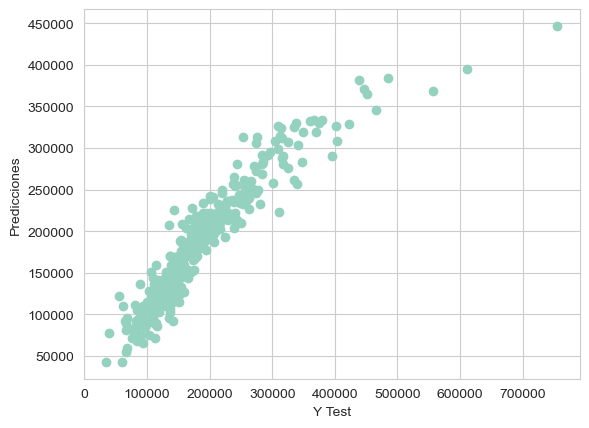

In [ ]:
plt.scatter(y_test, y_pred_elastic_net)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_elastic_net_mbe = mean_absolute_error(y_test, y_pred_elastic_net)
r_elastic_net_mse = mean_squared_error(y_test, y_pred_elastic_net)
r_elastic_net_rmse = np.sqrt(r_elastic_net_mse)
r_elastic_net_r2s = r2_score(y_test, y_pred_elastic_net)

print("MAE:", r_elastic_net_mbe)
print("MSE:", r_elastic_net_mse)
print("RMSE:", r_elastic_net_rmse)
print("R2_score:", r_elastic_net_r2s)

MAE: 19092.644514450523
MSE: 1022875827.422608
RMSE: 31982.42997995318
R2_score: 0.8534161531121472


## Red neuronal

In [ ]:
from sklearn.neural_network import MLPRegressor

r_red_neuronal = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
r_red_neuronal.fit(X_train_prepared, y_train)
r_red_neuronal.n_layers_

/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


4

**Predición:**

In [ ]:
y_pred_red_neuronal = r_red_neuronal.predict(X_test_prepared)

Text(0, 0.5, 'Predicciones')

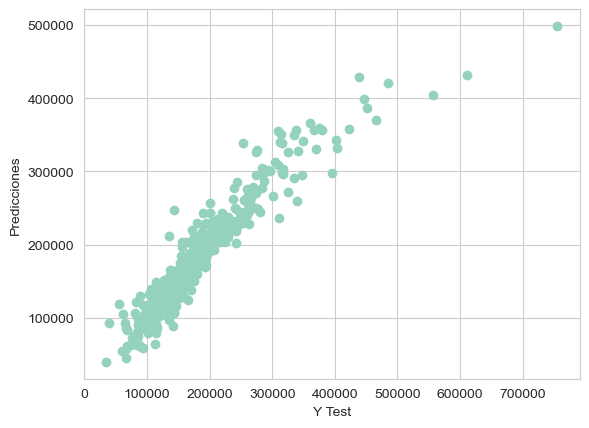

In [ ]:
plt.scatter(y_test, y_pred_red_neuronal)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_red_neuronal_mbe = mean_absolute_error(y_test, y_pred_red_neuronal)
r_red_neuronal_mse = mean_squared_error(y_test, y_pred_red_neuronal)
r_red_neuronal_rmse = np.sqrt(r_red_neuronal_mse)
r_red_neuronal_r2s = r2_score(y_test, y_pred_red_neuronal)

print("MAE:", r_red_neuronal_mbe)
print("MSE:", r_red_neuronal_mse)
print("RMSE:", r_red_neuronal_rmse)
print("R2_score:", r_red_neuronal_r2s)

MAE: 18108.365172016882
MSE: 817726165.9429247
RMSE: 28595.911699802906
R2_score: 0.8828152509901426


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

r_random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
r_random_forest.fit(X_train_prepared, y_train)
len(r_random_forest.estimators_)

100

**Predición:**

In [ ]:
y_pred_random_forest = r_random_forest.predict(X_test_prepared)

Text(0, 0.5, 'Predicciones')

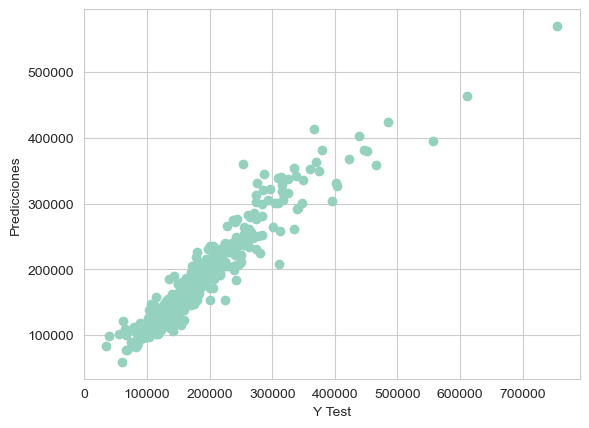

In [ ]:
plt.scatter(y_test, y_pred_random_forest)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_random_forest_mbe = mean_absolute_error(y_test, y_pred_random_forest)
r_random_forest_mse = mean_squared_error(y_test, y_pred_random_forest)
r_random_forest_rmse = np.sqrt(r_random_forest_mse)
r_random_forest_r2s = r2_score(y_test, y_pred_random_forest)

print("MAE:", r_random_forest_mbe)
print("MSE:", r_random_forest_mse)
print("RMSE:", r_random_forest_rmse)
print("R2_score:", r_random_forest_r2s)

MAE: 16774.448630136987
MSE: 713348258.5126983
RMSE: 26708.58024142613
R2_score: 0.8977731909385127


## XGBoost

In [ ]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from xgboost import XGBRegressor

r_xgboost = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
r_xgboost.fit(X_train_prepared, y_train)
r_xgboost.n_estimators

100

**Predición:**

In [ ]:
y_pred_xgboost = r_xgboost.predict(X_test_prepared)

Text(0, 0.5, 'Predicciones')

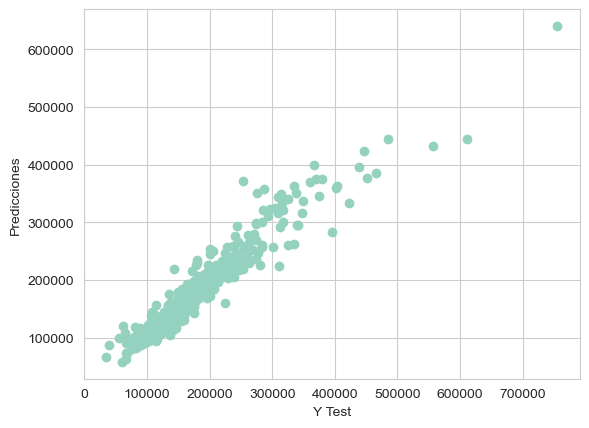

In [ ]:
plt.scatter(y_test, y_pred_xgboost)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_xgboost_mbe = mean_absolute_error(y_test, y_pred_xgboost)
r_xgboost_mse = mean_squared_error(y_test, y_pred_xgboost)
r_xgboost_rmse = np.sqrt(r_xgboost_mse)
r_xgboost_r2s = r2_score(y_test, y_pred_xgboost)

print("MAE:", r_xgboost_mbe)
print("MSE:", r_xgboost_mse)
print("RMSE:", r_xgboost_rmse)
print("R2_score:", r_xgboost_r2s)

MAE: 16426.443359375
MSE: 634489792.0
RMSE: 25189.08080895371
R2_score: 0.909074068069458


## Conclusión

Se evidencia que el mejor modelo hasta ahora es el XGBoost, con un R2_score de 0.9 y un error promedio de 25189 en las predicciones. Es un resultado bastante bueno considerando que el valor para SalePrice está en un rango entre 34900 y 755000. Sin embargo, se presentan algunos outliers. También, se observa que como resultado del one hot encoding, se crearon 313 columnas y de por sí, el dataset tiene 81 columnas o características, muchas de las cuales son redundantes, tienen una muy baja correlación y podrían removerse. Por último, se usaron unos hiperparámetros por defecto para las regresiones.

A continuación, se tratará de evaluar los mejores hiperparámetros para cada método, así como optimizar las características de los datos.

## Optimización de hiperparámetros para Lasso

Para optimizar los hiperparámetros, usamos GridSearchCV, que nos permite probar diferentes combinaciones de hiperparámetros y elegir la que tenga un mejor desempeño.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

param_grid = [
    {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100], 'max_iter': [5000, 10000]}
]

lasso_reg = Lasso(random_state=42)

grid_search = GridSearchCV(lasso_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

grid_search.fit(X_train_prepared, y_train)

**Mejores hiperparámetros:**

In [ ]:
grid_search.best_params_

{'alpha': 1, 'max_iter': 5000}

**Mejor modelo:**

In [ ]:
best_lasso = grid_search.best_estimator_
best_lasso

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


**Predición:**

In [ ]:
y_pred_best_lasso = best_lasso.predict(X_test_prepared)

**Evaluación:**

In [ ]:
best_lasso_mbe = mean_absolute_error(y_test, y_pred_best_lasso)
best_lasso_mse = mean_squared_error(y_test, y_pred_best_lasso)
best_lasso_rmse = np.sqrt(best_lasso_mse)
best_lasso_r2s = r2_score(y_test, y_pred_best_lasso)

print("MAE:", best_lasso_mbe)
print("MSE:", best_lasso_mse)
print("RMSE:", best_lasso_rmse)
print("R2_score:", best_lasso_r2s)

MAE: 20137.40364911381
MSE: 1998364744.0511014
RMSE: 44703.073094040206
R2_score: 0.7136231164967743


## Optimización de hiperparámetros para Ridge

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = [
    {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100, 1000]}
]

ridge_reg = Ridge(random_state=42)

grid_search_ridge = GridSearchCV(ridge_reg, param_grid, cv=5,
                                 scoring='neg_mean_squared_error',
                                 return_train_score=True)

grid_search_ridge.fit(X_train_prepared, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'alpha': [0.001, 0.01, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and

**Mejores hiperparámetros:**

In [ ]:
grid_search_ridge.best_params_

{'alpha': 0.001}

**Mejor modelo:**

In [ ]:
best_ridge = grid_search_ridge.best_estimator_
best_ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


**Predición:**

In [ ]:
y_pred_best_ridge = best_ridge.predict(X_test_prepared)

**Evaluación:**

In [ ]:
best_ridge_mbe = mean_absolute_error(y_test, y_pred_best_ridge)
best_ridge_mse = mean_squared_error(y_test, y_pred_best_ridge)
best_ridge_rmse = np.sqrt(best_ridge_mse)
best_ridge_r2s = r2_score(y_test, y_pred_best_ridge)

print("MAE:", best_ridge_mbe)
print("MSE:", best_ridge_mse)
print("RMSE:", best_ridge_rmse)
print("R2_score:", best_ridge_r2s)

MAE: 21103.130948416165
MSE: 2934924289.174907
RMSE: 54174.94152442536
R2_score: 0.5794088773063657


## Optimización de hiperparámetros para Elastic Net

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet

param_grid = [
    {
        'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'max_iter': [5000, 10000]
    }
]

elastic_net_reg = ElasticNet(random_state=42)

grid_search_elastic_net = GridSearchCV(elastic_net_reg, param_grid, cv=5,
                                       scoring='neg_mean_squared_error',
                                       return_train_score=True)

grid_search_elastic_net.fit(X_train_prepared, y_train)

/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.707e+11, tolerance: 4.742e+08
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.017e+11, tolerance: 4.840e+08
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increa

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'alpha': [0.001, 0.01, ...], 'l1_ratio': [0.1, 0.3, ...], 'max_iter': [5000, 10000]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

**Mejores hiperparámetros:**

In [ ]:
grid_search_elastic_net.best_params_

{'alpha': 0.5, 'l1_ratio': 0.3, 'max_iter': 5000}

**Mejor modelo:**

In [ ]:
best_elastic_net = grid_search_elastic_net.best_estimator_
best_elastic_net

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.5
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.3
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


**Predición:**

In [ ]:
y_pred_best_elastic_net = best_elastic_net.predict(X_test_prepared)

**Evaluación:**

In [ ]:
best_elastic_net_mbe = mean_absolute_error(y_test, y_pred_best_elastic_net)
best_elastic_net_mse = mean_squared_error(y_test, y_pred_best_elastic_net)
best_elastic_net_rmse = np.sqrt(best_elastic_net_mse)
best_elastic_net_r2s = r2_score(y_test, y_pred_best_elastic_net)

print("MAE:", best_elastic_net_mbe)
print("MSE:", best_elastic_net_mse)
print("RMSE:", best_elastic_net_rmse)
print("R2_score:", best_elastic_net_r2s)

MAE: 19458.761137412894
MSE: 1074834690.1925788
RMSE: 32784.67157365739
R2_score: 0.8459701564617702


## Optimización de hiperparámetros para Red Neuronal

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

param_grid = [
    {
        'hidden_layer_sizes': [(50,), (100,)],
        'alpha': [0.0001, 0.001],
        'learning_rate_init': [0.001, 0.01]
    }
]

red_neuronal_reg = MLPRegressor(max_iter=300, early_stopping=True, random_state=42)

grid_search_red_neuronal = GridSearchCV(red_neuronal_reg, param_grid, cv=3,
                                        scoring='neg_mean_squared_error',
                                        return_train_score=True)

grid_search_red_neuronal.fit(X_train_prepared, y_train)

/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'alpha': [0.0001, 0.001], 'hidden_layer_sizes': [(50,), (100,)], 'learning_rate_init': [0.001, 0.01]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

**Mejores hiperparámetros:**

In [ ]:
grid_search_red_neuronal.best_params_

{'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}

**Mejor modelo:**

In [ ]:
best_red_neuronal = grid_search_red_neuronal.best_estimator_
best_red_neuronal

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


**Predición:**

In [ ]:
y_pred_best_red_neuronal = best_red_neuronal.predict(X_test_prepared)

**Evaluación:**

In [ ]:
best_red_neuronal_mbe = mean_absolute_error(y_test, y_pred_best_red_neuronal)
best_red_neuronal_mse = mean_squared_error(y_test, y_pred_best_red_neuronal)
best_red_neuronal_rmse = np.sqrt(best_red_neuronal_mse)
best_red_neuronal_r2s = r2_score(y_test, y_pred_best_red_neuronal)

print("MAE:", best_red_neuronal_mbe)
print("MSE:", best_red_neuronal_mse)
print("RMSE:", best_red_neuronal_rmse)
print("R2_score:", best_red_neuronal_r2s)

MAE: 21850.46799999712
MSE: 1258415733.1649537
RMSE: 35474.15584851814
R2_score: 0.8196619626682171


## Optimización de hiperparámetros para Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    {
        'n_estimators': [50, 100],
        'max_depth': [None, 10],
        'max_features': ['sqrt', 0.5]
    }
]

random_forest_reg = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search_random_forest = GridSearchCV(random_forest_reg, param_grid, cv=3,
                                         scoring='neg_mean_squared_error',
                                         return_train_score=True,
                                         n_jobs=-1)

grid_search_random_forest.fit(X_train_prepared, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_depth': [None, 10], 'max_features': ['sqrt', 0.5], 'n_estimators': [50, 100]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

**Mejores hiperparámetros:**

In [ ]:
grid_search_random_forest.best_params_

{'max_depth': None, 'max_features': 0.5, 'n_estimators': 100}

**Mejor modelo:**

In [ ]:
best_random_forest = grid_search_random_forest.best_estimator_
best_random_forest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

**Predición:**

In [ ]:
y_pred_best_random_forest = best_random_forest.predict(X_test_prepared)

**Evaluación:**

In [ ]:
best_random_forest_mbe = mean_absolute_error(y_test, y_pred_best_random_forest)
best_random_forest_mse = mean_squared_error(y_test, y_pred_best_random_forest)
best_random_forest_rmse = np.sqrt(best_random_forest_mse)
best_random_forest_r2s = r2_score(y_test, y_pred_best_random_forest)

print("MAE:", best_random_forest_mbe)
print("MSE:", best_random_forest_mse)
print("RMSE:", best_random_forest_rmse)
print("R2_score:", best_random_forest_r2s)

MAE: 16493.881872146118
MSE: 704835552.8472481
RMSE: 26548.739195058737
R2_score: 0.8989931094373298


## Optimización de hiperparámetros para XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = [
    {
        'n_estimators': [50, 100, 200],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
]

xgboost_reg = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

grid_search_xgboost = GridSearchCV(xgboost_reg, param_grid, cv=3,
                                   scoring='neg_mean_squared_error',
                                   return_train_score=True,
                                   n_jobs=-1)

grid_search_xgboost.fit(X_train_prepared, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

**Mejores hiperparámetros:**

In [ ]:
grid_search_xgboost.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 2,
 'n_estimators': 200,
 'subsample': 0.8}

**Mejor modelo:**

In [ ]:
best_xgboost = grid_search_xgboost.best_estimator_
best_xgboost

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

**Predición:**

In [ ]:
y_pred_best_xgboost = best_xgboost.predict(X_test_prepared)

**Evaluación:**

In [ ]:
best_xgboost_mbe = mean_absolute_error(y_test, y_pred_best_xgboost)
best_xgboost_mse = mean_squared_error(y_test, y_pred_best_xgboost)
best_xgboost_rmse = np.sqrt(best_xgboost_mse)
best_xgboost_r2s = r2_score(y_test, y_pred_best_xgboost)

print("MAE:", best_xgboost_mbe)
print("MSE:", best_xgboost_mse)
print("RMSE:", best_xgboost_rmse)
print("R2_score:", best_xgboost_r2s)

MAE: 16570.041015625
MSE: 626220352.0
RMSE: 25024.39513754528
R2_score: 0.9102591276168823


## Comparación de modelos

In [ ]:
model_comparison = pd.DataFrame([
    {
        'Modelo': 'Regresión Lineal',
        'RMSE original': lm_rmse,
        'RMSE optimizado': np.nan,
        'Cambio RMSE': np.nan,
        'R2_score original': lm_r2s,
        'R2_score optimizado': np.nan,
        'Cambio R2_score': np.nan
    },
    {
        'Modelo': 'Regresión Lasso',
        'RMSE original': r_lasso_rmse,
        'RMSE optimizado': best_lasso_rmse,
        'Cambio RMSE': best_lasso_rmse - r_lasso_rmse,
        'R2_score original': r_lasso_r2s,
        'R2_score optimizado': best_lasso_r2s,
        'Cambio R2_score': best_lasso_r2s - r_lasso_r2s
    },
    {
        'Modelo': 'Regresión Ridge',
        'RMSE original': r_ridge_rmse,
        'RMSE optimizado': best_ridge_rmse,
        'Cambio RMSE': best_ridge_rmse - r_ridge_rmse,
        'R2_score original': r_ridge_r2s,
        'R2_score optimizado': best_ridge_r2s,
        'Cambio R2_score': best_ridge_r2s - r_ridge_r2s
    },
    {
        'Modelo': 'Regresión Elastic Net',
        'RMSE original': r_elastic_net_rmse,
        'RMSE optimizado': best_elastic_net_rmse,
        'Cambio RMSE': best_elastic_net_rmse - r_elastic_net_rmse,
        'R2_score original': r_elastic_net_r2s,
        'R2_score optimizado': best_elastic_net_r2s,
        'Cambio R2_score': best_elastic_net_r2s - r_elastic_net_r2s
    },
    {
        'Modelo': 'Red Neuronal',
        'RMSE original': r_red_neuronal_rmse,
        'RMSE optimizado': best_red_neuronal_rmse,
        'Cambio RMSE': best_red_neuronal_rmse - r_red_neuronal_rmse,
        'R2_score original': r_red_neuronal_r2s,
        'R2_score optimizado': best_red_neuronal_r2s,
        'Cambio R2_score': best_red_neuronal_r2s - r_red_neuronal_r2s
    },
    {
        'Modelo': 'Random Forest',
        'RMSE original': r_random_forest_rmse,
        'RMSE optimizado': best_random_forest_rmse,
        'Cambio RMSE': best_random_forest_rmse - r_random_forest_rmse,
        'R2_score original': r_random_forest_r2s,
        'R2_score optimizado': best_random_forest_r2s,
        'Cambio R2_score': best_random_forest_r2s - r_random_forest_r2s
    },
    {
        'Modelo': 'XGBoost',
        'RMSE original': r_xgboost_rmse,
        'RMSE optimizado': best_xgboost_rmse,
        'Cambio RMSE': best_xgboost_rmse - r_xgboost_rmse,
        'R2_score original': r_xgboost_r2s,
        'R2_score optimizado': best_xgboost_r2s,
        'Cambio R2_score': best_xgboost_r2s - r_xgboost_r2s
    }
])

model_comparison

,Modelo,RMSE original,RMSE optimizado,Cambio RMSE,R2_score original,R2_score optimizado,Cambio R2_score
0,Regresión Lineal,86581.402452,NaN,NaN,-0.074267,NaN,NaN
1,Regresión Lasso,29383.391823,44703.073094,15319.681271,0.876272,0.713623,-0.162649
2,Regresión Ridge,28304.053975,54174.941524,25870.887549,0.885195,0.579409,-0.305786
3,Regresión Elastic Net,31982.429980,32784.671574,802.241594,0.853416,0.845970,-0.007446
4,Red Neuronal,28595.911700,35474.155849,6878.244149,0.882815,0.819662,-0.063153
5,Random Forest,26708.580241,26548.739195,-159.841046,0.897773,0.898993,0.001220
6,XGBoost,25189.080809,25024.395138,-164.685671,0.909074,0.910259,0.001185


# Conclusión

Se evidencia que algunos modelos empeoraron con los nuevos hiperparámetros. Sin embargo, se podrá usar los nuevos hiperparámetros para probar limpiando y optimizando el dataset. Se procede a limpiar algunos datos y eliminar algunas columnas, tratando de dejar la más relevantes.

Hasta ahora, se puede decir que los mejores modelos son el Random Forest, el XGBoost y la regresion rigde. Se utilizarán dichos modelos para comparar usando el dataset optimizado.

# Optimizando el dataset

Se inicia mirando las caracteristicas más importantes para el modelo de Random Forest, esto da una pista de que características tienen más relación con la variable objetivo y se deberían usar para construir el modelo.

In [ ]:
feature_importances = grid_search_random_forest.best_estimator_.feature_importances_
feature_importances

array([7.47639354e-03, 1.99000130e-02, 3.36998162e-01, 2.71098162e-03,
       2.68858637e-02, 8.46498326e-03, 4.65436300e-03, 2.41439515e-02,
       7.02021048e-04, 6.07887476e-03, 3.97429473e-02, 2.45292510e-02,
       3.13367854e-02, 9.57761344e-05, 1.22926930e-01, 1.83687262e-03,
       7.37371952e-05, 1.61765542e-02, 1.08205435e-03, 2.63632082e-03,
       9.51512362e-04, 7.89764733e-03, 4.58896237e-03, 7.23155290e-03,
       7.39328932e-02, 2.28133960e-02, 5.51726241e-03, 5.93519476e-03,
       3.89592360e-04, 2.81381280e-04, 4.60721250e-03, 1.64297307e-03,
       5.28136738e-05, 3.15962473e-03, 1.56160899e-03, 1.14798688e-04,
       7.07547015e-05, 2.02299163e-06, 1.61079315e-05, 4.41714895e-04,
       2.00375838e-04, 9.68223692e-06, 4.96312564e-06, 1.61071208e-04,
       1.65325554e-03, 2.49068381e-04, 1.82455326e-04, 5.36530557e-05,
       2.86566495e-06, 4.47922296e-05, 3.03617525e-06, 1.35559402e-04,
       3.07420037e-05, 7.20280338e-04, 1.09250646e-03, 6.32851842e-07,
      

In [ ]:
cat_pipeline = full_pipeline.named_transformers_["cat"]
cat_encoder = cat_pipeline.named_steps["onehot"]
cat_one_hot_attributes = cat_encoder.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_one_hot_attributes)

feature_importance_table = pd.DataFrame({
    "Característica": feature_names,
    "Importancia": feature_importances
}).sort_values("Importancia", ascending=False)

feature_importance_table.head(20)

,Característica,Importancia
2,OverallQual,0.336998
14,GrLivArea,0.122927
24,GarageCars,0.073933
182,ExterQual_TA,0.069230
10,TotalBsmtSF,0.039743
12,2ndFlrSF,0.031337
4,YearBuilt,0.026886
11,1stFlrSF,0.024529
7,BsmtFinSF1,0.024144
25,GarageArea,0.022813


In [ ]:
feature_importance_table.shape

(313, 2)

In [ ]:
importance_threshold = 0.01

selected_features = feature_importance_table[
    feature_importance_table["Importancia"] > importance_threshold
]["Característica"].tolist()

pd.DataFrame({"Característica": selected_features})

,Característica
0,OverallQual
1,GrLivArea
2,GarageCars
3,ExterQual_TA
4,TotalBsmtSF
5,2ndFlrSF
6,YearBuilt
7,1stFlrSF
8,BsmtFinSF1
9,GarageArea


Como resultado, se tiene que solo 13 características tienen una importancia mayor a 0.01, por lo cual se usarán solo esas 13 para entrenar los modelos.

In [ ]:
X_train_prepared_df = pd.DataFrame.sparse.from_spmatrix(
    X_train_prepared,
    columns=feature_names,
    index=X_train.index
)

X_train_modified = X_train_prepared_df[selected_features]

X_train_modified.shape

(1022, 13)

## Regresión lineal con características seleccionadas

In [ ]:
lm_modified = LinearRegression()
lm_modified.fit(X_train_modified, y_train)
len(lm_modified.coef_)

13

**Predicción:**

In [ ]:
X_test_prepared_df = pd.DataFrame.sparse.from_spmatrix(
    X_test_prepared,
    columns=feature_names,
    index=X_test.index
)

X_test_modified = X_test_prepared_df[selected_features]

In [ ]:
y_pred_modified = lm_modified.predict(X_test_modified)

Text(0, 0.5, 'Predicciones')

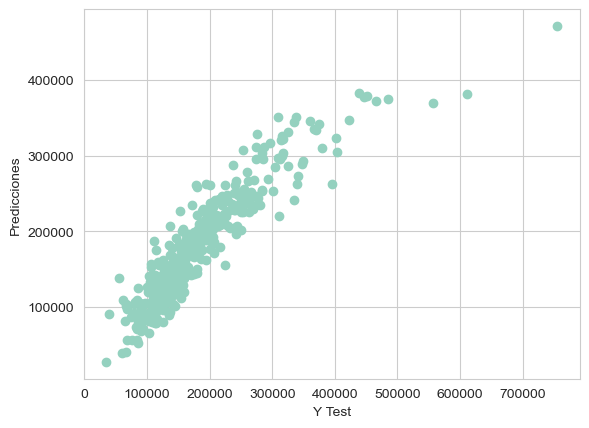

In [ ]:
plt.scatter(y_test, y_pred_modified)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
lm_modified_mbe = mean_absolute_error(y_test, y_pred_modified)
lm_modified_mse = mean_squared_error(y_test, y_pred_modified)
lm_modified_rmse = np.sqrt(lm_modified_mse)
lm_modified_r2s = r2_score(y_test, y_pred_modified)

print("MAE:", lm_modified_mbe)
print("MSE:", lm_modified_mse)
print("RMSE:", lm_modified_rmse)
print("R2_score:", lm_modified_r2s)

MAE: 22864.90996899709
MSE: 1207851463.4775403
RMSE: 34754.15749917613
R2_score: 0.8269081063028088


## Regresión Ridge con características seleccionadas

In [ ]:
r_ridge_modified = Ridge(**grid_search_ridge.best_params_)
r_ridge_modified.fit(X_train_modified, y_train)
len(r_ridge_modified.coef_)

13

**Predicción:**

In [ ]:
y_pred_ridge_modified = r_ridge_modified.predict(X_test_modified)

Text(0, 0.5, 'Predicciones')

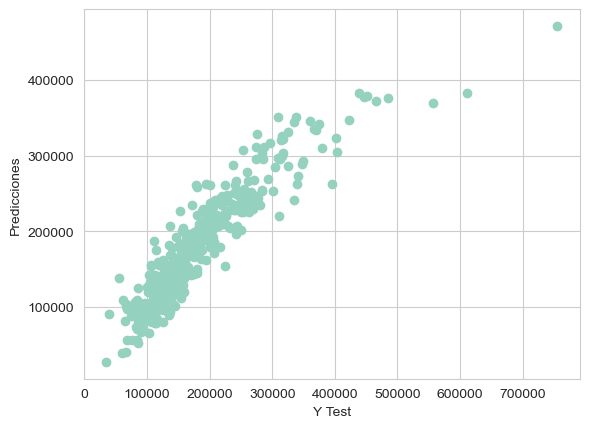

In [ ]:
plt.scatter(y_test, y_pred_ridge_modified)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_ridge_modified_mbe = mean_absolute_error(y_test, y_pred_ridge_modified)
r_ridge_modified_mse = mean_squared_error(y_test, y_pred_ridge_modified)
r_ridge_modified_rmse = np.sqrt(r_ridge_modified_mse)
r_ridge_modified_r2s = r2_score(y_test, y_pred_ridge_modified)

print("MAE:", r_ridge_modified_mbe)
print("MSE:", r_ridge_modified_mse)
print("RMSE:", r_ridge_modified_rmse)
print("R2_score:", r_ridge_modified_r2s)

MAE: 22866.274118987836
MSE: 1208640940.7998273
RMSE: 34765.51367087544
R2_score: 0.8267949697716394


## Random Forest con características seleccionadas

In [ ]:
r_random_forest_modified = RandomForestRegressor(
    **grid_search_random_forest.best_params_,
    random_state=42,
    n_jobs=-1
)
r_random_forest_modified.fit(X_train_modified, y_train)
len(r_random_forest_modified.estimators_)

100

**Predicción:**

In [ ]:
y_pred_random_forest_modified = r_random_forest_modified.predict(X_test_modified)

Text(0, 0.5, 'Predicciones')

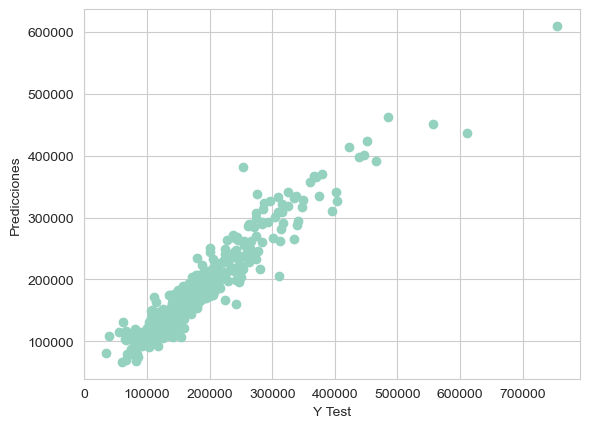

In [ ]:
plt.scatter(y_test, y_pred_random_forest_modified)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_random_forest_modified_mbe = mean_absolute_error(y_test, y_pred_random_forest_modified)
r_random_forest_modified_mse = mean_squared_error(y_test, y_pred_random_forest_modified)
r_random_forest_modified_rmse = np.sqrt(r_random_forest_modified_mse)
r_random_forest_modified_r2s = r2_score(y_test, y_pred_random_forest_modified)

print("MAE:", r_random_forest_modified_mbe)
print("MSE:", r_random_forest_modified_mse)
print("RMSE:", r_random_forest_modified_rmse)
print("R2_score:", r_random_forest_modified_r2s)

MAE: 16998.436415525113
MSE: 676531458.8279335
RMSE: 26010.21835409948
R2_score: 0.9030492449650223


## XGBoost con características seleccionadas

In [ ]:
r_xgboost_modified = XGBRegressor(
    **grid_search_xgboost.best_params_,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)
r_xgboost_modified.fit(X_train_modified, y_train)
r_xgboost_modified.n_estimators

/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/xgboost/data.py:400: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


200

**Predicción:**

In [ ]:
y_pred_xgboost_modified = r_xgboost_modified.predict(X_test_modified)

/opt/anaconda3/envs/ml_env/lib/python3.14/site-packages/xgboost/data.py:400: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


Text(0, 0.5, 'Predicciones')

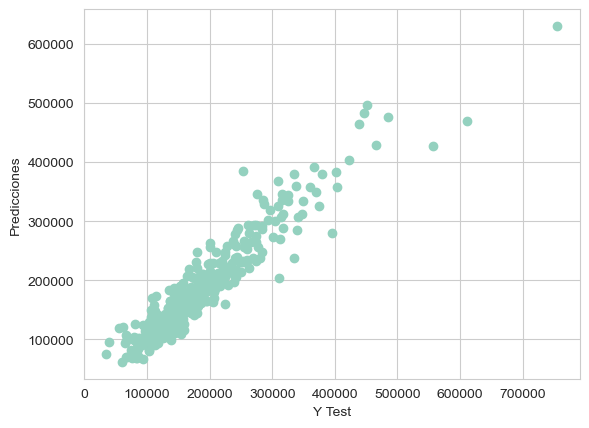

In [ ]:
plt.scatter(y_test, y_pred_xgboost_modified)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")

**Evaluación:**

In [ ]:
r_xgboost_modified_mbe = mean_absolute_error(y_test, y_pred_xgboost_modified)
r_xgboost_modified_mse = mean_squared_error(y_test, y_pred_xgboost_modified)
r_xgboost_modified_rmse = np.sqrt(r_xgboost_modified_mse)
r_xgboost_modified_r2s = r2_score(y_test, y_pred_xgboost_modified)

print("MAE:", r_xgboost_modified_mbe)
print("MSE:", r_xgboost_modified_mse)
print("RMSE:", r_xgboost_modified_rmse)
print("R2_score:", r_xgboost_modified_r2s)

MAE: 18681.607421875
MSE: 733190272.0
RMSE: 27077.48644169174
R2_score: 0.8949297070503235


## Comparación de RMSE y R2 por versión del dataset

In [ ]:
model_version_comparison = pd.DataFrame([
    {
        "Modelo": "Regresión Lineal",
        "RMSE": lm_rmse,
        "RMSE optimizado": np.nan,
        "RMSE dataset modificado": lm_modified_rmse,
        "R2": lm_r2s,
        "R2 optimizado": np.nan,
        "R2 dataset modificado": lm_modified_r2s
    },
    {
        "Modelo": "Regresión Ridge",
        "RMSE": r_ridge_rmse,
        "RMSE optimizado": best_ridge_rmse,
        "RMSE dataset modificado": r_ridge_modified_rmse,
        "R2": r_ridge_r2s,
        "R2 optimizado": best_ridge_r2s,
        "R2 dataset modificado": r_ridge_modified_r2s
    },
    {
        "Modelo": "Random Forest",
        "RMSE": r_random_forest_rmse,
        "RMSE optimizado": best_random_forest_rmse,
        "RMSE dataset modificado": r_random_forest_modified_rmse,
        "R2": r_random_forest_r2s,
        "R2 optimizado": best_random_forest_r2s,
        "R2 dataset modificado": r_random_forest_modified_r2s
    },
    {
        "Modelo": "XGBoost",
        "RMSE": r_xgboost_rmse,
        "RMSE optimizado": best_xgboost_rmse,
        "RMSE dataset modificado": r_xgboost_modified_rmse,
        "R2": r_xgboost_r2s,
        "R2 optimizado": best_xgboost_r2s,
        "R2 dataset modificado": r_xgboost_modified_r2s
    }
])

model_version_comparison

,Modelo,RMSE,RMSE optimizado,RMSE dataset modificado,R2,R2 optimizado,R2 dataset modificado
0,Regresión Lineal,86581.402452,NaN,34754.157499,-0.074267,NaN,0.826908
1,Regresión Ridge,28304.053975,54174.941524,34766.327450,0.885195,0.579409,0.826787
2,Random Forest,26708.580241,26548.739195,26010.218354,0.897773,0.898993,0.903049
3,XGBoost,25189.080809,25024.395138,27077.486442,0.909074,0.910259,0.894930


# Conclusiones

Se evindencia que el método que más mejoró después de modificar el dataset fue el Randon Forest, que alcanzó un `R2_score` de 0.9 y un error promedio de $26010. Se podría validar probando otras combinaciones pero en general el resultado es bastante satisfatorio.

Tanto por correlación como por importancia dada por Random Forest, se tiene que la característica `OverallQual` es la que más está correlacionada con el precio de venta del inmueble (`SalePrice`). Esto tiene sentido ya que esta variable califica de manera general los materiales y acabados del inmueble, usando para esto una escala de 1 a 10, y se puede suponer que esto tiene relación con el precio. Se puede observar la correlación en el siguiente gráfico, donde se muestra que para valores altos de `OverallQual`, se tienen también precios de venta altos:

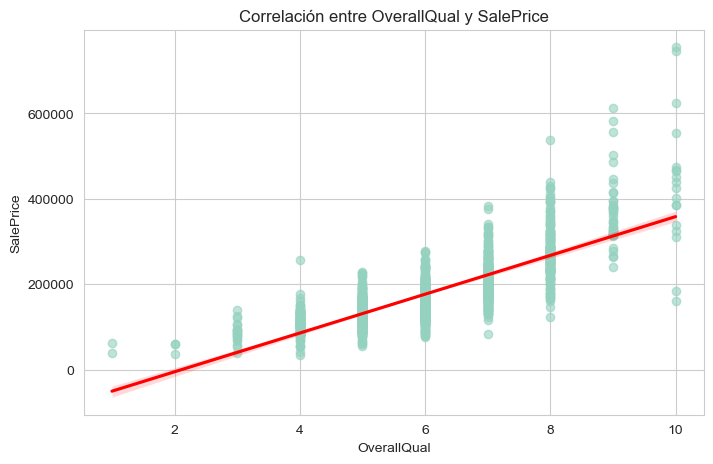

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=housing, x="OverallQual", y="SalePrice", scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Correlación entre OverallQual y SalePrice")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.show()

Es importante notar que este dataset es de prueba, quizás con datos reales el desempeño sea menor. Adicionalmente se evidenció que tener en cuenta todas las características para entrenar el modelo puede afectar el resultado.

En general, el mejor modelo fue el XGBoost con un `R2_score` de 0.91 y un error promedio de $25024 después de optimizar los parámetros, obteniendo que la mejor combinación fue:


```
{
  'colsample_bytree': 1.0,
  'learning_rate': 0.1,
  'max_depth': 2,
  'n_estimators': 200,
  'subsample': 0.8
}
```

Usando 200 estimadores y un 0.1 para la tasa de aprendizaje. Se puede observar como es el desempeño del modelo en el siguiente gráfico. Se ve que se sigue una tendencia casi lineal, indicando el buen resultado del modelo con los parámetros optimizados (antes de haber modifcado el dataset):

Text(0.5, 1.0, 'Predicciones de best_xgboost')

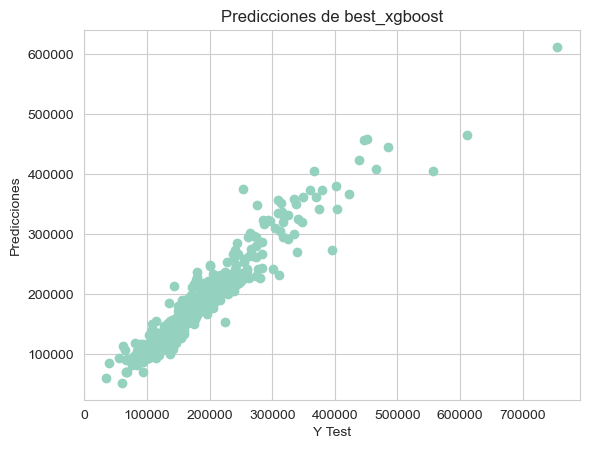

In [ ]:
plt.scatter(y_test, y_pred_best_xgboost)
plt.xlabel("Y Test")
plt.ylabel("Predicciones")
plt.title("Predicciones de best_xgboost")

Sin embargo, como se mostró anteriormente, al probar el modelo con el dataset modificando (descartando las columnas que no eran importantes), el desempeño bajó ligeramente. Esto se puede deber a que la selección de las columnas se hizo basado en los resultados de Random Forest. Se pueden probar otras combinaciones y ver si se obtiene un resultado mejor.